In [242]:
import random
import pandas as pd
import numpy as np

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_15min"

df = pd.read_csv(f'datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.8 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [243]:
def build_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['close'] - df.iloc[i]['close']) / df.iloc[i]['close'])
            vectors.append(cur_vec)
    return np.array(vectors)

X_train = build_vectors_by_price(df_train, N)
X_train.shape

(276, 19)

**Строим векторы отношений цен для трейна**

In [244]:
X_train[0]

array([0.0539439 , 0.06458931, 0.06746584, 0.06880839, 0.06784944,
       0.0723088 , 0.07137377, 0.06784944, 0.07499401, 0.07806281,
       0.07715176, 0.07801491, 0.07520978, 0.07879549, 0.07705586,
       0.06883241, 0.07027092, 0.06765764, 0.06847279])

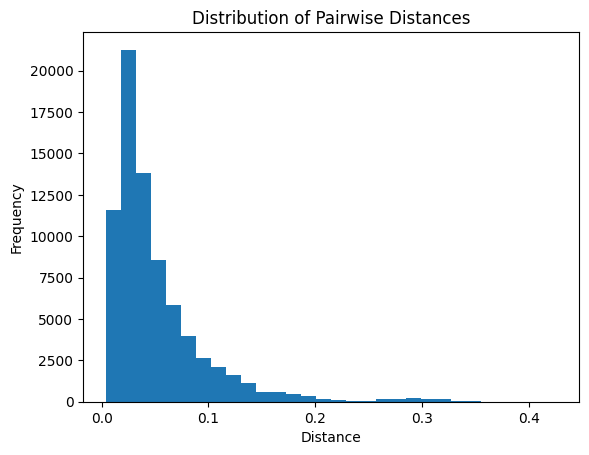

In [245]:
from matplotlib import pyplot as plt

distances = [[0] * X_train.shape[0] for _ in range(X_train.shape[0])]
for i in range(X_train.shape[0]):
    for j in range(i + 1, X_train.shape[0]):
        dist = np.linalg.norm(X_train[i] - X_train[j])
        distances[i][j] = dist
        distances[j][i] = dist

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [246]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.04
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train)
clustering_dbscan.labels_

array([-1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1, -1,  0, -1, -1, -1,  0, -1,  0,  0,  0, -1,
        0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [247]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([  0, 141, 158, 159, 161, 162, 163, 165, 169, 171, 177, 190, 193])

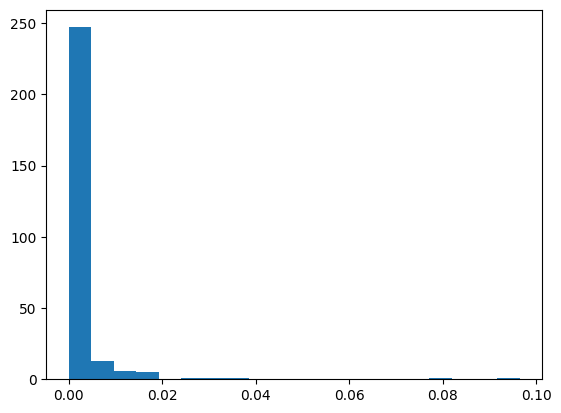

In [248]:
squared = np.diagonal(X_train @ X_train.T)
plt.hist(squared, bins=20)
plt.show()

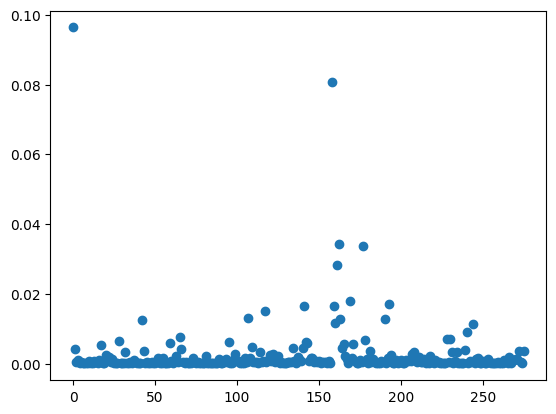

In [249]:
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [250]:
squared[noise]

array([0.09639928, 0.0166048 , 0.08062122, 0.01638593, 0.02813581,
       0.03425945, 0.01288142, 0.00555188, 0.01783378, 0.00552026,
       0.03363109, 0.0126828 , 0.01714834])

In [251]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train)
clustering_kmeans.labels_

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0], dtype=int32)

**Проверяем DBSCAN accuracy на тесте**

In [252]:
X_test = build_vectors_by_price(df_test, N, take_all=True)

In [253]:
from sklearn.metrics.pairwise import euclidean_distances

def predict_dbscan(X_train, v, eps):
    # Расстояния от v до всех core points
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    # Если ближайший core point в пределах eps — присваиваем его кластер
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1  # шум

accuracy = 0
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train, X_test[i - N], EPS)
    if (prediction == -1 and not df_test.iloc[i]['is_min']) or (prediction != -1 and df_test.iloc[i]['is_min']):
        accuracy += 1
accuracy /= len(X_test)
print(accuracy)

0.03787878787878788


**Проверяем Kmeans accuracy на тесте**

In [254]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1  # считаем выбросом
    
    return label

accuracy = 0
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    if (prediction == -1 and not df_test.iloc[i]['is_min']) or (prediction != -1 and df_test.iloc[i]['is_min']):
        accuracy += 1
accuracy /= len(X_test)
print(accuracy)

0.17323232323232324
